In [16]:
import numpy as np
import matplotlib.pyplot as plt

from utils.data import DataManager
from utils.tools import BENCHMARKS, RISK_ANALYSIS, INTERPRETATION_THRESHOLDS

from utils.analysis.risk_metrics import (
    VarEsAnalyzer, VarEsReporter,
    RatioAnalyzer, RatioReporter,
    DistributionAnalyzer, DistributionReporter,
    BenchmarkAnalyzer, BenchmarkReporter,
    DrawdownAnalyzer, DrawdownReporter,
    CorrelationAnalyzer, CorrelationReporter
)

from utils.visualizations import (
    DrawdownVisualizer, 
    DistributionVisualizer, 
    VarEsVisualizer, 
    RatioVisualizer, 
    BenchmarkVisualizer
)

from utils.analysis.risk_metrics.components import calculate_portfolio_returns

In [2]:
TICKERS = ["META", "AAPL", "GOOGL", "NVDA", "MSFT"] 
BENCHMARK_NAME = "SP500" 
START_DATE = "2020-01-01" 
END_DATE = "2024-12-31"

In [15]:
BENCHMARK_TICKER = BENCHMARKS[BENCHMARK_NAME] 
RISK_FREE_RATE = RISK_ANALYSIS['risk_free_rate']
ANNUAL_FACTOR = RISK_ANALYSIS['annual_factor']
DEFAULT_CONFIDENCE = RISK_ANALYSIS['default_confidence_level']
CONFIDENCE_LEVELS = RISK_ANALYSIS['default_confidence_levels']
ROLLING_WINDOW = RISK_ANALYSIS['rolling']['default_window']
MC_SIMULATIONS = RISK_ANALYSIS['monte_carlo']['n_simulations']
MC_SEED = RISK_ANALYSIS['monte_carlo']['seed']
WEIGHTS = np.ones(len(TICKERS)) / len(TICKERS)

In [ ]:
data_manager = DataManager()


var_es_analyzer = VarEsAnalyzer(annual_factor=ANNUAL_FACTOR)
ratio_analyzer = RatioAnalyzer(annual_factor=ANNUAL_FACTOR)
dist_analyzer = DistributionAnalyzer()
benchmark_analyzer = BenchmarkAnalyzer(annual_factor=ANNUAL_FACTOR)
drawdown_analyzer = DrawdownAnalyzer(annual_factor=ANNUAL_FACTOR)
correlation_analyzer = CorrelationAnalyzer()


var_es_reporter = VarEsReporter(var_es_analyzer)
ratio_reporter = RatioReporter(ratio_analyzer)
dist_reporter = DistributionReporter(dist_analyzer)
benchmark_reporter = BenchmarkReporter(benchmark_analyzer)
drawdown_reporter = DrawdownReporter(drawdown_analyzer)
correlation_reporter = CorrelationReporter(correlation_analyzer)


ratio_viz = RatioVisualizer(annual_factor=ANNUAL_FACTOR)
benchmark_viz = BenchmarkVisualizer(annual_factor=ANNUAL_FACTOR)
dist_viz = DistributionVisualizer()
drawdown_viz = DrawdownVisualizer()
var_es_viz = VarEsVisualizer(annual_factor=ANNUAL_FACTOR)


In [5]:
assets_prices, benchmark_prices = data_manager.download_portfolio_with_benchmark(
    tickers=TICKERS,
    benchmark_name=BENCHMARK_NAME,
    start_date=START_DATE,
    end_date=END_DATE
)

returns = assets_prices.pct_change().dropna()
benchmark_returns = benchmark_prices.pct_change().dropna()

Descargando portafolio completo...
Período: 2020-01-01 → 2024-12-31


[*********************100%***********************]  5 of 5 completed


Período: 2020-01-01 → 2024-12-31


[*********************100%***********************]  1 of 1 completed

Portafolio descargado: 5 activos + benchmark


               VaR y ES - Comparación de Métodos (95%)                
             ANÁLISIS VaR y ES (Nivel de confianza: 95%)              

COMPARACIÓN DE MÉTODOS
Método          VaR Diario      VaR Anual       ES Diario       ES Anual       
Historical        -3.32%       -52.74%        -4.65%       -73.79%
Parametric        -3.21%       -50.98%        -4.07%       -64.53%
Monte_carlo       -3.27%       -51.93%        -4.13%       -65.49%
INTERPRETACIÓN
VaR promedio diario:     -3.27%
ES promedio diario:      -4.28%
Pérdida máxima esperada: -4.28% en un día adverso
  Nivel de riesgo:         Moderado


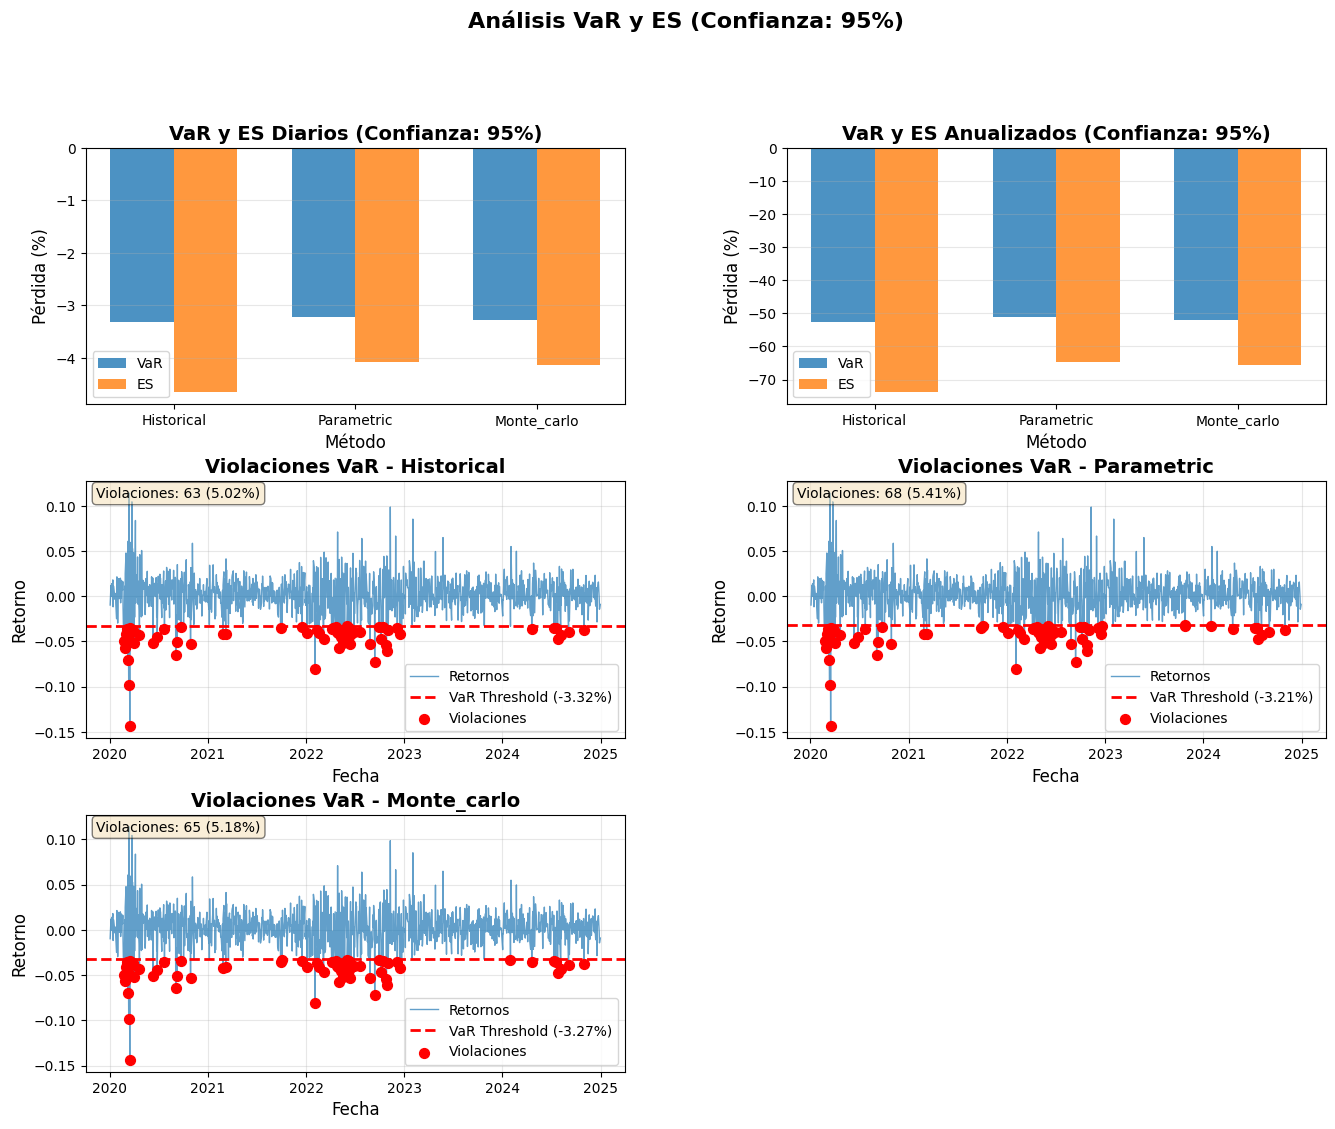

In [6]:
var_es_results = var_es_analyzer.calculate_multi_level(
    returns=returns,
    weights=WEIGHTS,
    confidence_levels=CONFIDENCE_LEVELS,
    n_simulations=MC_SIMULATIONS,
    seed=MC_SEED
)

print("VaR y ES - Comparación de Métodos (95%)".center(70))

comparison_df = var_es_reporter._results_to_dataframe(var_es_results[0.95])
var_es_reporter.print_comparison(comparison_df, confidence_level=0.95)

fig = var_es_viz.plot_var_es_analysis(
    returns=returns,
    weights=WEIGHTS,
    var_es_results=var_es_results,  
    confidence_level=0.95,
    figsize=(16, 12)
)
plt.show()


                  Ratios Rolling (Sharpe & Sortino)                   
                RESUMEN DE MÉTRICAS ROLLING                 

SHARPE RATIO ROLLING
  Promedio:                   1.235
  Mínimo:                    -1.375
  Máximo:                     3.055
  Último:                     2.001

SORTINO RATIO ROLLING
  Promedio:                   1.987
  Mínimo:                    -2.114
  Máximo:                     6.031
  Último:                     2.856


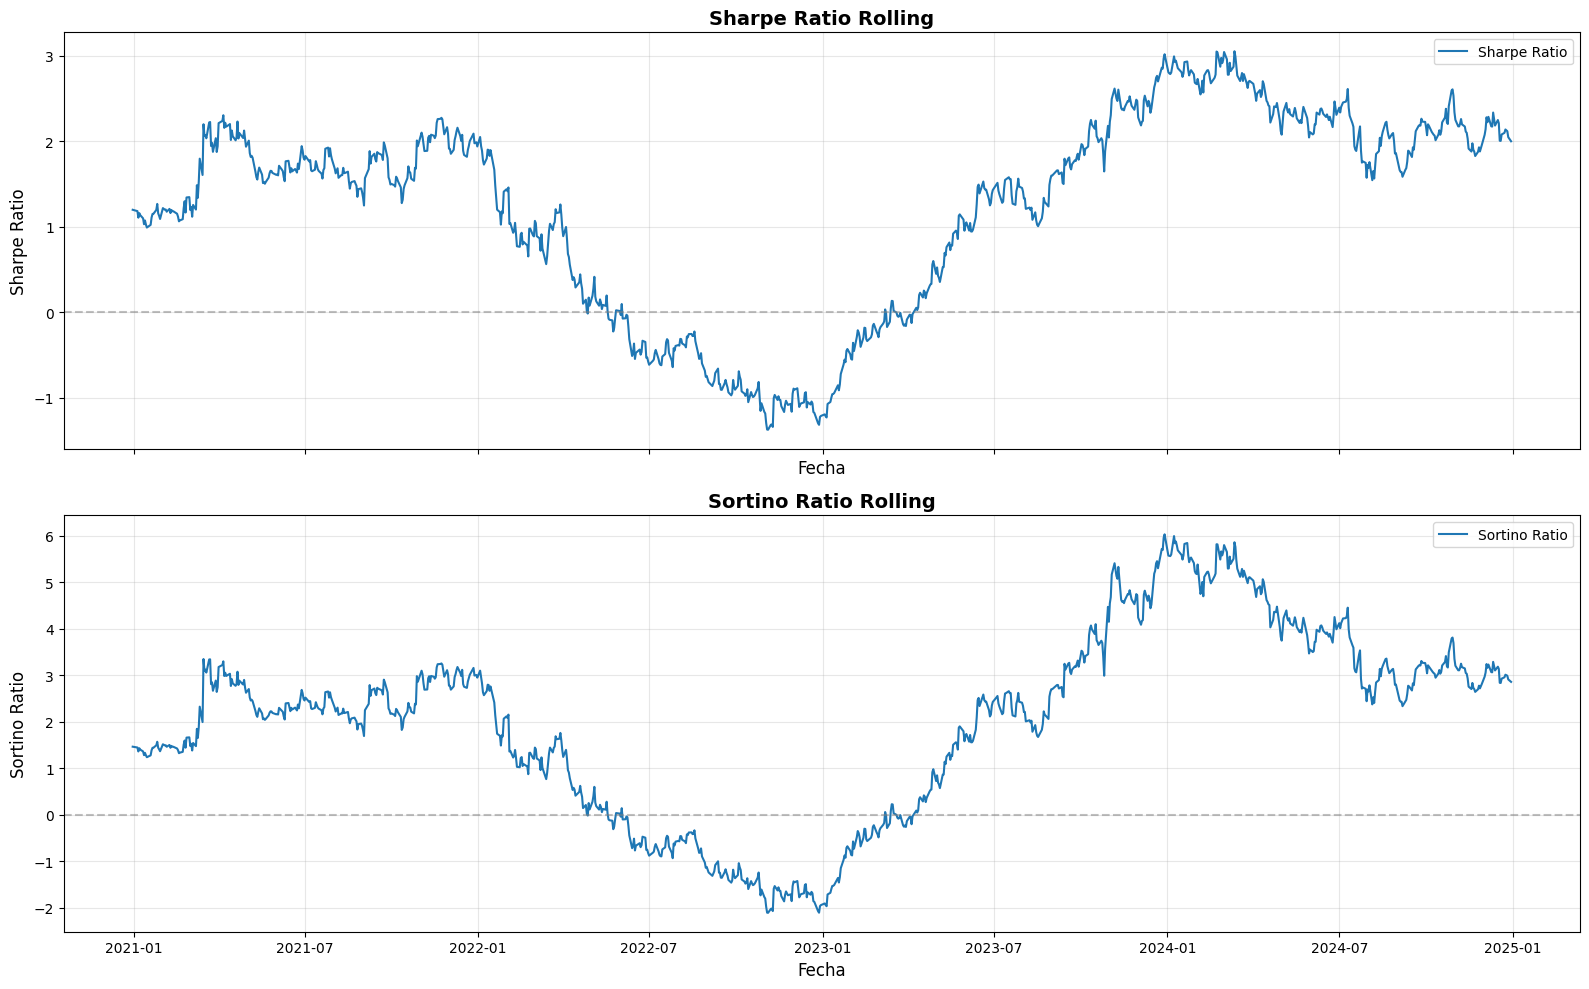

In [7]:
# Calcular rolling Sharpe y Sortino (1 sola vez)
rolling_ratios = ratio_analyzer.calculate_rolling(
    returns=returns,
    weights=WEIGHTS,
    risk_free_rate=RISK_FREE_RATE,
    window=ROLLING_WINDOW
)

# Reporte
print("\n" + "="*70)
print("Ratios Rolling (Sharpe & Sortino)".center(70))
print("="*70)
ratio_reporter.print_rolling_summary(rolling_ratios)

# Visualización
fig = ratio_viz.plot_rolling_ratios(rolling_ratios, figsize=(16, 10))
plt.show()


                         Análisis de Drawdown                         
                    ANÁLISIS DE DRAWDOWN                    
MAX DRAWDOWN
  Magnitud:                  -48.53%
  Fecha:                   2022-11-03 00:00:00
  Duración:                355 días
RATIOS DE DRAWDOWN
  Calmar Ratio:               0.781
  Sterling Ratio:             0.818
RETORNO ANUAL
  Retorno Anual:              37.90%
INTERPRETACIÓN
  Nivel de riesgo:         Muy Alto
  Calmar:                  Buena compensación


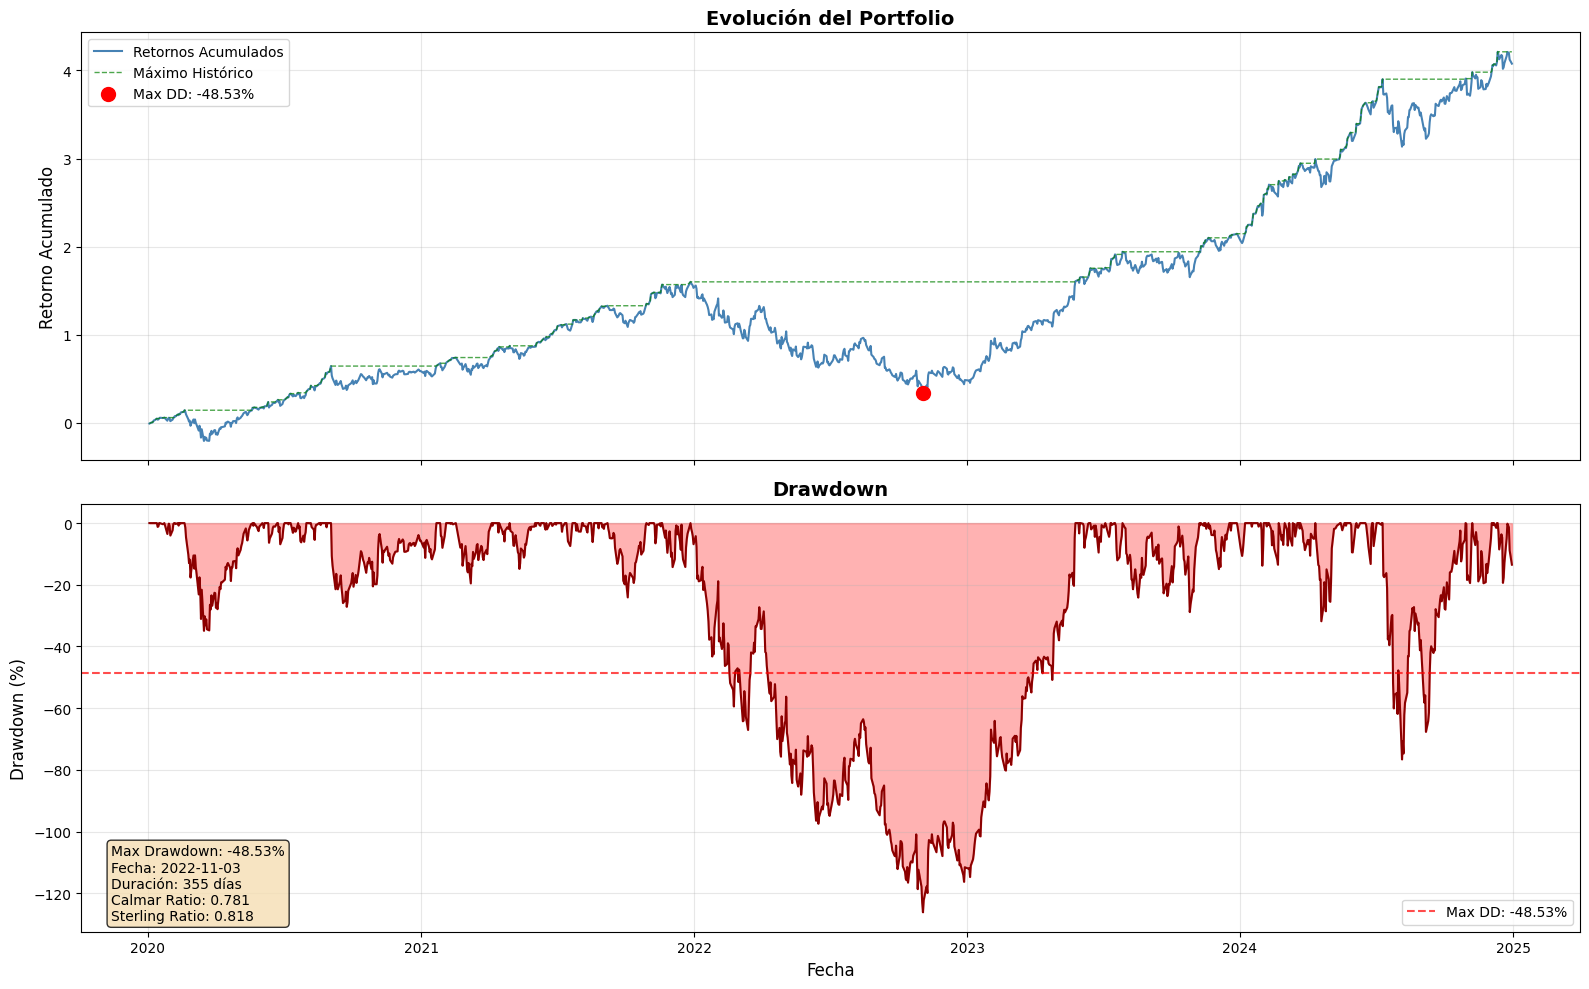

In [ ]:
# Calcular drawdown (1 sola vez)
dd_results = drawdown_analyzer.analyze(
    returns=returns,
    weights=WEIGHTS
)

drawdown_reporter.print_drawdown(dd_results)

# Visualización
fig = drawdown_viz.plot_drawdown_analysis(
    returns=returns,
    weights=WEIGHTS,
    dd_results=dd_results,
    figsize=(16, 10)
)
plt.show()


                       Análisis de Distribución                       
                  ANÁLISIS DE DISTRIBUCIÓN                  
ASIMETRÍA (Skewness)
  Valor:                     -0.180
  Interpretación:          Aproximadamente simétrica
CURTOSIS (Excess Kurtosis)
  Valor:                      4.771
  Interpretación:          Leptocúrtica (colas pesadas)
                           -> Mayor riesgo de eventos extremos
TEST DE NORMALIDAD (Jarque-Bera)
  Estadístico JB:           1186.10
  p-value:                   0.0000
  Distribución normal:     [NO]


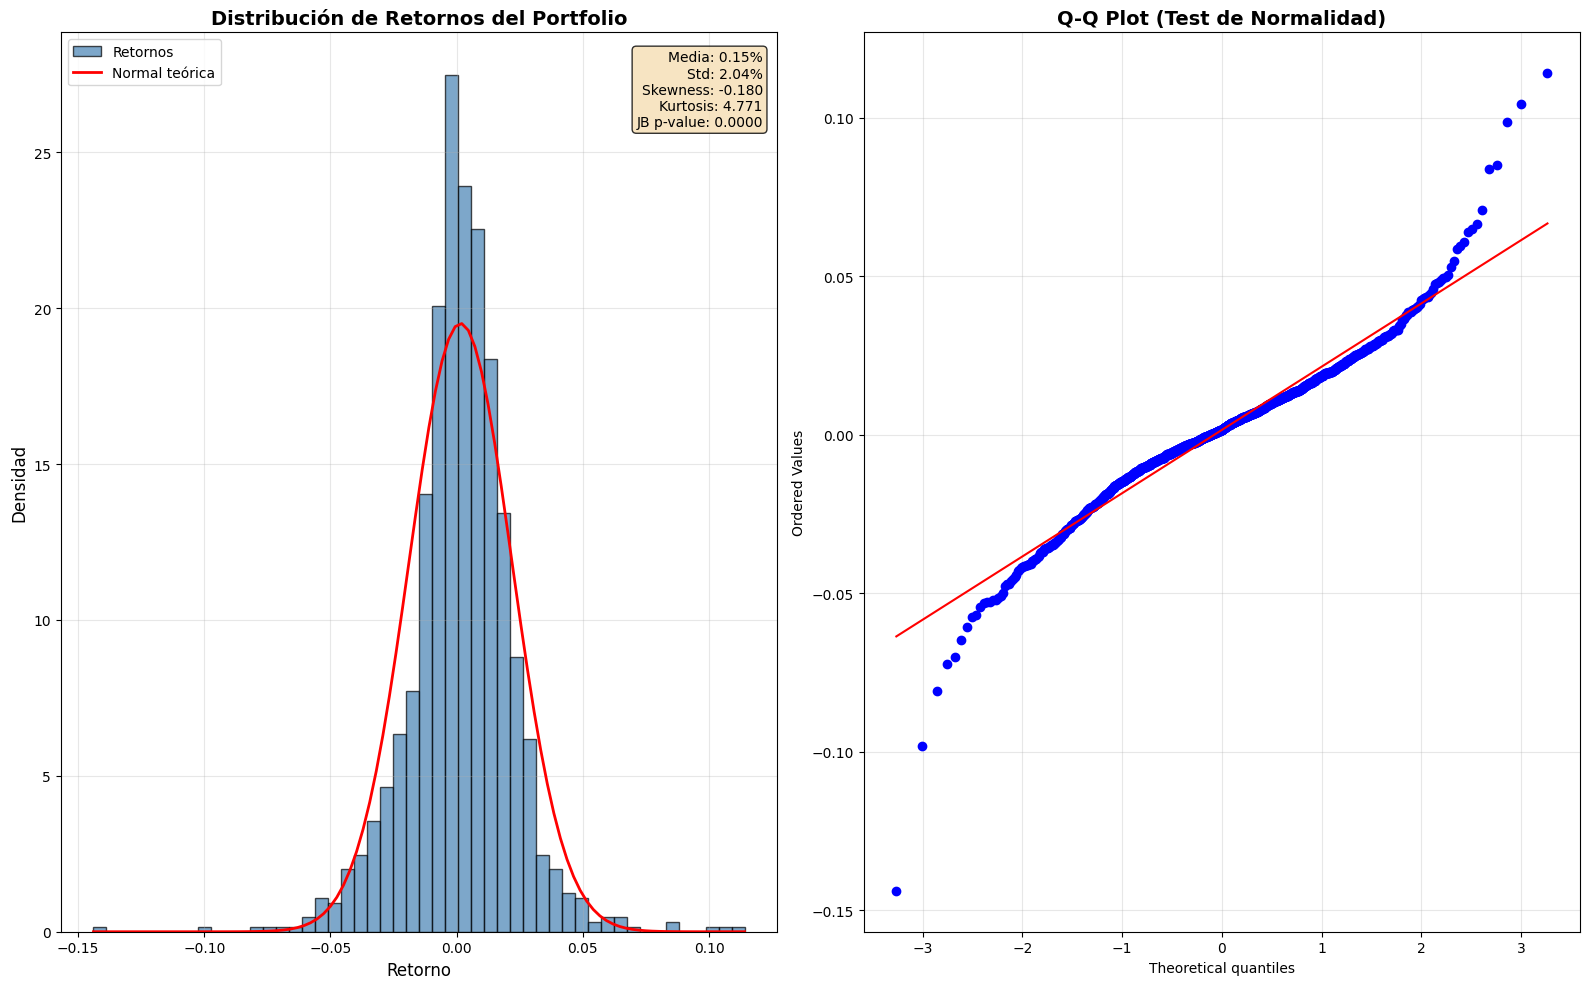

In [ ]:
dist_results = dist_analyzer.analyze(
    returns=returns,
    weights=WEIGHTS
)

dist_reporter.print_distribution(dist_results)

fig = dist_viz.plot_distribution_analysis(
    returns=returns,
    weights=WEIGHTS,
    dist_results=dist_results,
    figsize=(16, 10)
)
plt.show()

In [ ]:
# Calcular métricas vs benchmark (1 sola vez)
benchmark_results = benchmark_analyzer.analyze(
    returns=returns,
    weights=WEIGHTS,
    benchmark_returns=benchmark_returns,
    risk_free_rate=RISK_FREE_RATE
)

benchmark_reporter.print_benchmark_analysis(benchmark_results)


                    Análisis vs Benchmark (SP500)                     
                   ANÁLISIS VS BENCHMARK                    
TRACKING ERROR
  Tracking Error (diario):      1.12%
  Tracking Error (anual):      17.78%
  Interpretación:          Alta desviación del benchmark

INFORMATION RATIO
  Information Ratio:           1.331
  Interpretación:          Excelente - supera al benchmark
BETA
  Beta:                        1.309
  R²:                          0.741
  Correlación:                 0.861
  Interpretación:          Alta sensibilidad (agresivo)
ALPHA (Jensen)
  Alpha (anualizado):          20.66%
  Retorno cartera:             37.90%
  Retorno benchmark:           14.23%
  Retorno esperado (CAPM):     17.24%
  Interpretación:          Excelente - supera expectativas



                    Tracking Error y Beta Rolling                     


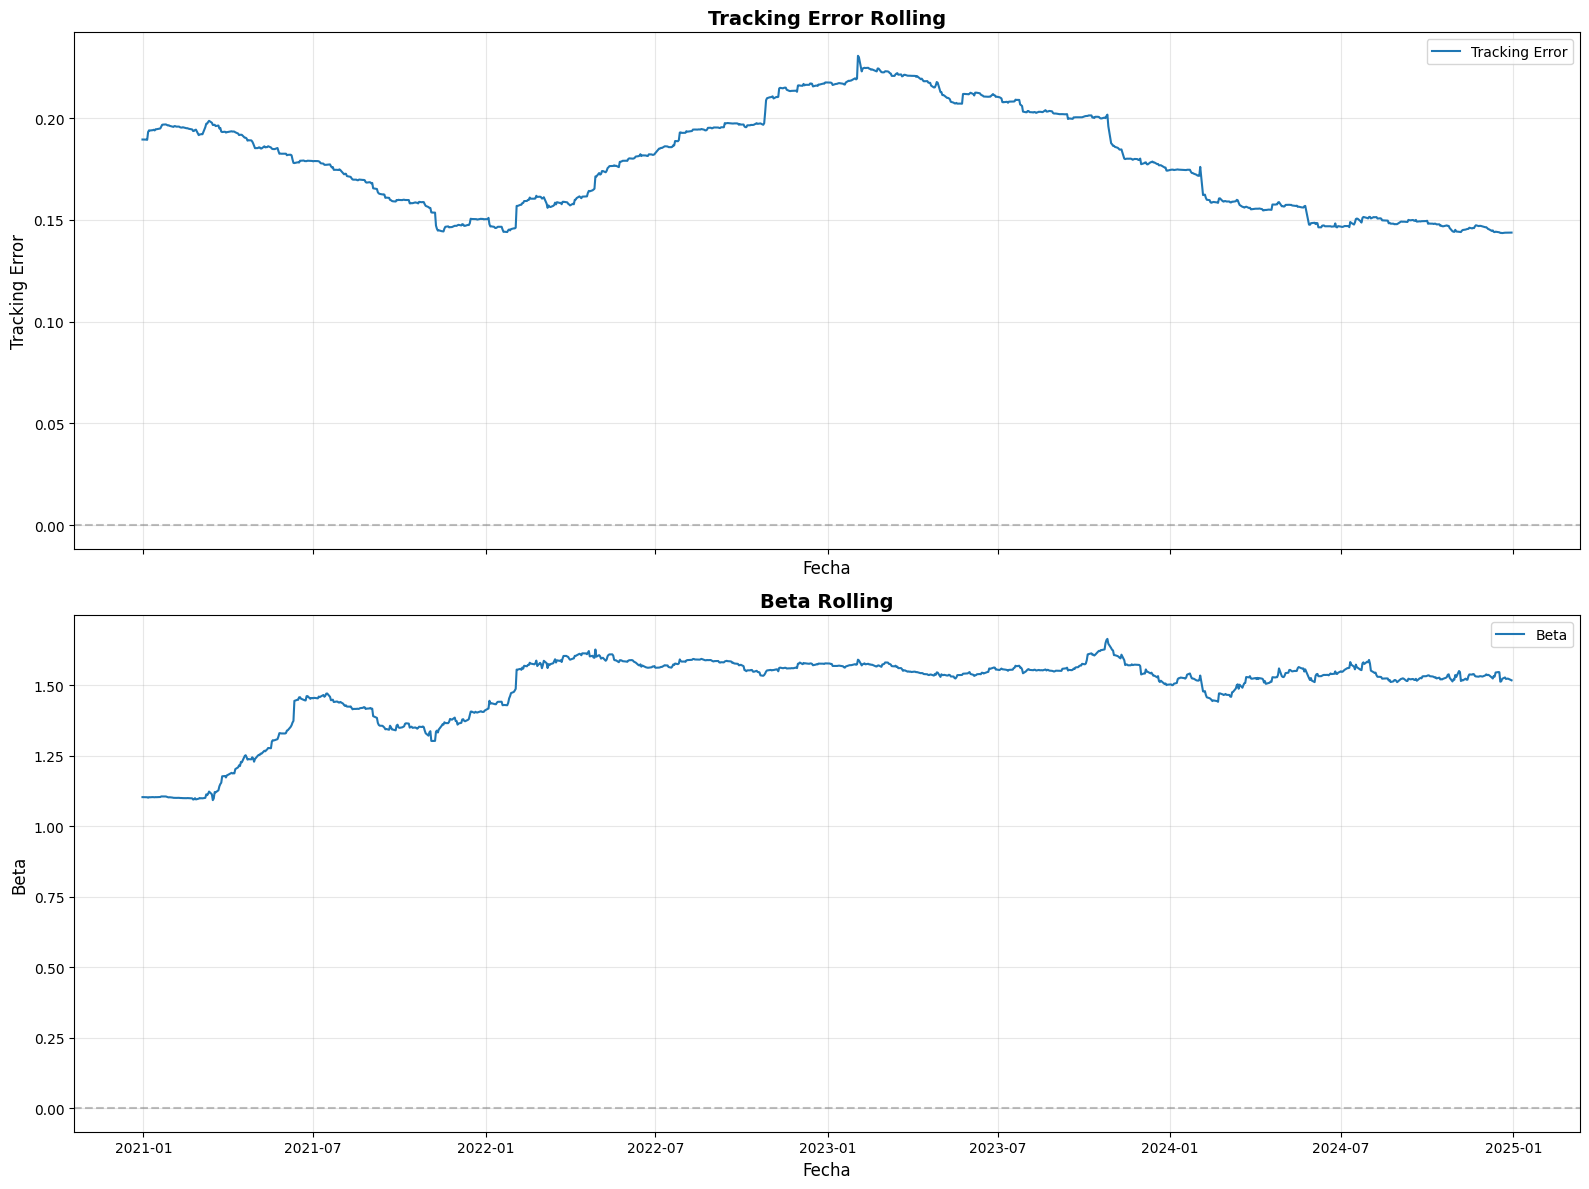

In [ ]:
# Calcular rolling benchmark metrics (1 sola vez)
rolling_benchmark = benchmark_analyzer.analyze_rolling(
    returns=returns,
    weights=WEIGHTS,
    benchmark_returns=benchmark_returns,
    window=ROLLING_WINDOW
)

fig = benchmark_viz.plot_rolling_benchmark(
    rolling_data=rolling_benchmark,
    figsize=(16, 12)
)
plt.show()

In [14]:
# Calcular matriz de correlación (1 sola vez)
corr_results = correlation_analyzer.analyze(returns=returns)
correlation_reporter.print_correlation_summary(corr_results)

                  ANÁLISIS DE CORRELACIÓN                   
MATRIZ DE CORRELACIÓN
        META   AAPL  GOOGL   NVDA   MSFT
META   1.000  0.563  0.641  0.535  0.620
AAPL   0.563  1.000  0.649  0.606  0.748
GOOGL  0.641  0.649  1.000  0.594  0.746
NVDA   0.535  0.606  0.594  1.000  0.682
MSFT   0.620  0.748  0.746  0.682  1.000

ESTADÍSTICAS DE CORRELACIÓN
  Correlación promedio:       0.638
  Correlación máxima:         0.748
  Correlación mínima:         0.535
  Desviación estándar:        0.067
PARES MÁS CORRELACIONADOS
  AAPL - MSFT:   0.748
  GOOGL - MSFT:   0.746
  NVDA - MSFT:   0.682
PARES MENOS CORRELACIONADOS
  META - NVDA:   0.535
  META - AAPL:   0.563
  GOOGL - NVDA:   0.594


In [ ]:
portfolio_ret = calculate_portfolio_returns(returns, WEIGHTS)
annual_return = portfolio_ret.mean() * ANNUAL_FACTOR
annual_vol = portfolio_ret.std() * np.sqrt(ANNUAL_FACTOR)
sharpe = (annual_return - RISK_FREE_RATE) / annual_vol

print(f"\n📊 PORTAFOLIO")
print(f"  Activos:                 {', '.join(TICKERS)}")
print(f"  Período:                 {START_DATE} → {END_DATE}")
print(f"  Pesos:                   Equitativo ({WEIGHTS[0]:.1%} cada uno)")

print(f"\n📈 RETORNO Y VOLATILIDAD")
print(f"  Retorno anual:           {annual_return*100:>8.2f}%")
print(f"  Volatilidad anual:       {annual_vol*100:>8.2f}%")
print(f"  Sharpe Ratio:            {sharpe:>8.3f}")

print(f"\n⚠️ RIESGO (VaR 95%)")
var_95 = var_es_results[0.95]['historical']['var_daily_pct']
es_95 = var_es_results[0.95]['historical']['es_daily_pct']
print(f"  VaR 95% (diario):        {var_95:>8.2f}%")
print(f"  ES 95% (diario):         {es_95:>8.2f}%")

print(f"\n📉 DRAWDOWN")
print(f"  Max Drawdown:            {dd_results['max_drawdown']*100:>8.2f}%")
print(f"  Calmar Ratio:            {dd_results['calmar_ratio']:>8.3f}")

print(f"\n🎯 VS BENCHMARK ({BENCHMARK_NAME})")
print(f"  Alpha anual:             {benchmark_results['alpha_annual']*100:>8.2f}%")
print(f"  Beta:                    {benchmark_results['beta']:>8.3f}")
print(f"  Information Ratio:       {benchmark_results['information_ratio']:>8.3f}")
print(f"  Tracking Error:          {benchmark_results['tracking_error_annual']*100:>8.2f}%")

print(f"\n📊 DISTRIBUCIÓN")
print(f"  Skewness:                {dist_results['skewness']:>8.3f}")
print(f"  Excess Kurtosis:         {dist_results['excess_kurtosis']:>8.3f}")
print(f"  Normal (Jarque-Bera):    {'[NO]' if not dist_results['is_normal'] else '[SI]'}")

print("\n" + "="*70)


                RESUMEN EJECUTIVO - ANÁLISIS DE RIESGO                

📊 PORTAFOLIO
  Activos:                 META, AAPL, GOOGL, NVDA, MSFT
  Período:                 2020-01-01 → 2024-12-31
  Pesos:                   Equitativo (20.0% cada uno)

📈 RETORNO Y VOLATILIDAD
  Retorno anual:              37.90%
  Volatilidad anual:          32.46%
  Sharpe Ratio:               1.029

⚠️ RIESGO (VaR 95%)
  VaR 95% (diario):           -3.32%
  ES 95% (diario):            -4.65%

📉 DRAWDOWN
  Max Drawdown:              -48.53%
  Calmar Ratio:               0.781

🎯 VS BENCHMARK (SP500)
  Alpha anual:                20.66%
  Beta:                       1.309
  Information Ratio:          1.331
  Tracking Error:             17.78%

📊 DISTRIBUCIÓN
  Skewness:                  -0.180
  Excess Kurtosis:            4.771
  Normal (Jarque-Bera):    [NO]

